# 0a. Data Exploration

Load data, inspect the hierarchy, audit quality, visualise basic
psychometric curves, summary statistics, and update matrices.

This notebook is a **reference** — it shows how to access and visualise
data at every level of the hierarchy. It does not perform any analysis;
adaptation analysis lives in 4a, model comparison in 3a–3c, etc.

In [1]:
%matplotlib inline
from shared_setup import *

## 1. Load Data

In [2]:
config = Path('/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/config_cluster.yaml')
experiment, load_info = load_data(config_path=config)

Loaded snapshot: 22 animals, 885 sessions (exported 2026-04-25)


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:194: UserWarning: Snapshot is 102h old (exported 2026-04-25T14:21:53.133522+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(


## 2. Data Hierarchy

```
ExperimentData
└── AnimalData  (one per mouse)
    └── SessionData  (one per day)
        ├── SessionMetadata  (stage, contingency, stim range, ...)
        └── TrialData  (stimulus, choice, outcome, RT, opto, ...)
```

In [3]:
# ── Experiment overview ─────────────────────────────────────────────────────
print("=== Experiment ===")
print(experiment.summary().to_string(index=False))

# ── Pick first animal for detailed inspection ───────────────────────────────
animal = experiment.get_animal(experiment.animal_ids[0])
print(f"\n=== Animal: {animal.animal_id} ===")
print(f"  Sessions: {animal.n_sessions}, Stages: {animal.stages}")
print(f"  Dates: {animal.sessions[0].date} → {animal.sessions[-1].date}")

# ── Session-level detail ────────────────────────────────────────────────────
session = animal.sessions[-1]
print(f"\n=== Session: {session.session_id} ===")
print(f"  Stage: {session.stage}, Distribution: {session.distribution}")
print(
    f"  Trials: {session.n_trials} total, "
    f"{session.trials.valid_mask.sum()} valid, "
    f"{session.trials.abort.sum()} abort"
)

# ── Trial-level spot check ──────────────────────────────────────────────────
trials = session.trials
print(f"\n=== TrialData ===")
print(f"  stimulus range: [{trials.stimulus.min():.2f}, {trials.stimulus.max():.2f}]")
print(f"  choice values: {np.unique(trials.choice[~np.isnan(trials.choice)])}")
print(f"  opto trials: {trials.opto_on.sum()}")

=== Experiment ===
animal_id  n_sessions                                                               stages date_first  date_last
     SS01          74       [Habituation, Three_And_Three, Full_Task_Disc, Full_Task_Cont] 2025-11-15 2026-04-24
     SS02          20   [Lick_To_Release, Three_And_Three, Full_Task_Disc, Full_Task_Cont] 2025-11-16 2026-01-15
     SS04          92 [, Lick_To_Release, Three_And_Three, Full_Task_Disc, Full_Task_Cont] 2025-11-15 2026-04-24
     SS05          66      [Habituation, Lick_To_Release, Three_And_Three, Full_Task_Cont] 2026-01-06 2026-04-24
     SS06          65                   [Lick_To_Release, Three_And_Three, Full_Task_Cont] 2026-01-21 2026-04-24
     SS07          65                   [Lick_To_Release, Three_And_Three, Full_Task_Cont] 2026-01-21 2026-04-24
     SS08          65                   [Lick_To_Release, Three_And_Three, Full_Task_Cont] 2026-01-21 2026-04-24
     SS09          56      [Habituation, Lick_To_Release, Three_And_Three, Fu

## 3. Session Table

In [4]:
rows = [s.summary() for s in animal.sessions]
session_df = pd.DataFrame(rows)
session_df['perf'] = session_df['perf'].round(3)
print(f"Sessions for {animal.animal_id}:")
cols = ['session_id', 'session_idx', 'date', 'stage',
        'distribution', 'n_trials', 'n_valid', 'perf']
cols = [c for c in cols if c in session_df.columns]
print(session_df[cols].to_string(index=False))

Sessions for SS01:
               session_id  session_idx       date           stage distribution  n_trials  n_valid  perf
SOUND_CAT_SS01_2025_11_15            0 2025-11-15     Habituation      Uniform       369        0   NaN
SOUND_CAT_SS01_2025_11_17            1 2025-11-17 Three_And_Three      Uniform       418      418 0.610
SOUND_CAT_SS01_2025_11_18            2 2025-11-18 Three_And_Three      Uniform       595      595 0.697
  SOUND_CAT_SS01_2026_1_5            3 2026-01-05  Full_Task_Disc      Uniform       420      399 0.757
 SOUND_CAT_SS01_2026_1_12            4 2026-01-12  Full_Task_Cont      Uniform       600      557 0.623
 SOUND_CAT_SS01_2026_1_13            5 2026-01-13  Full_Task_Cont      Uniform       399      388 0.647
 SOUND_CAT_SS01_2026_1_14            6 2026-01-14  Full_Task_Cont      Uniform       462      430 0.595
 SOUND_CAT_SS01_2026_1_15            7 2026-01-15  Full_Task_Cont      Uniform       476      462 0.671
 SOUND_CAT_SS01_2026_1_16            8 2026-0

## 4. Psychometric Curves

Multiple ways to visualise psychometric behaviour, from single
sessions to pooled across sessions.

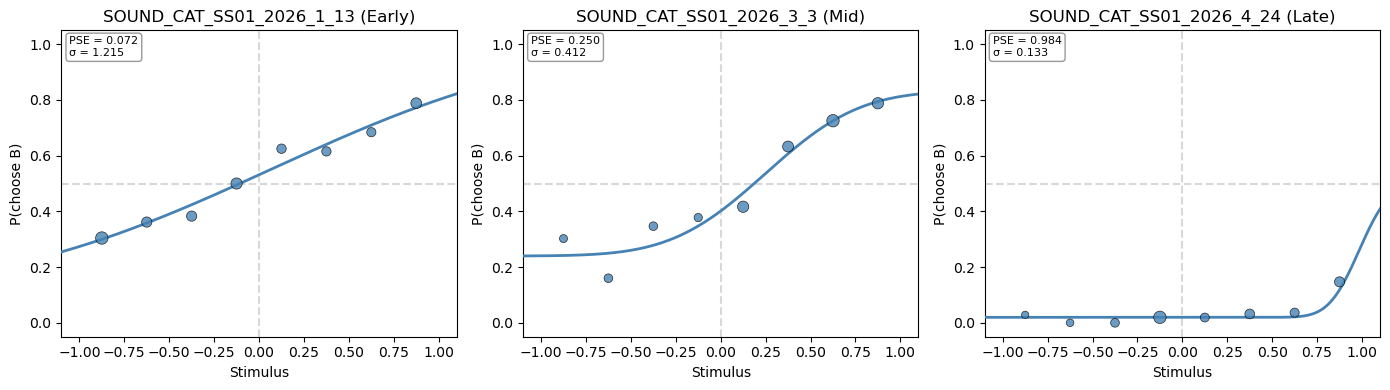

In [5]:
# ── Single sessions at different learning stages ────────────────────────────
sessions = animal.get_sessions(stage=STAGE)
n_sess = len(sessions)

# Pick early, mid, late
indices = [min(1, n_sess - 1), n_sess // 2, n_sess - 1]
labels = ['Early', 'Mid', 'Late']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, idx, label in zip(axes, indices, labels):
    s = sessions[idx]
    arrays = s.trials.get_arrays()
    valid = ~arrays['no_response']
    plot_psychometric(
        arrays['stimuli'][valid], arrays['choices'][valid],
        ax=ax, title=f'{s.session_id} ({label})',
    )
plt.tight_layout()
plt.show()

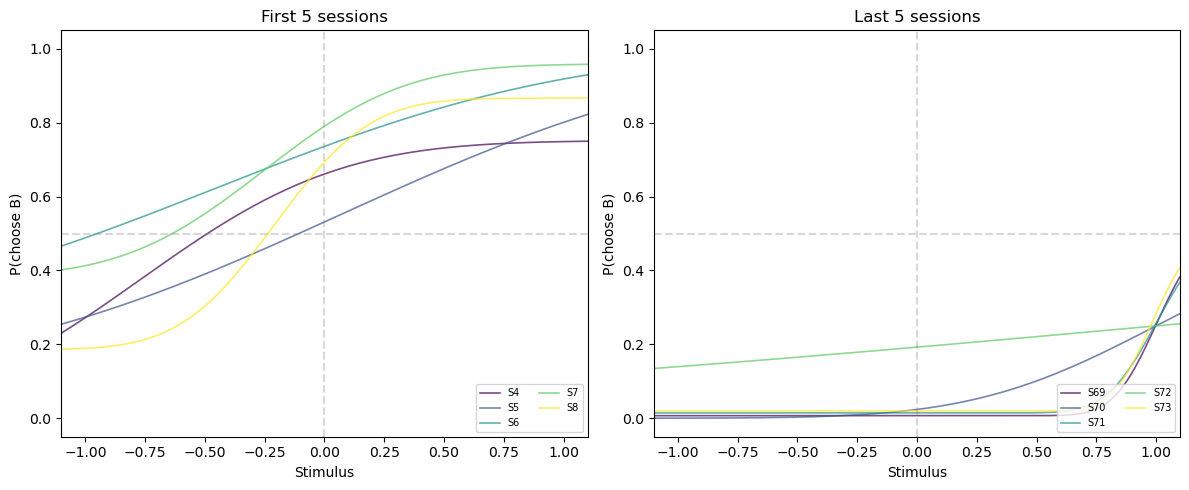

In [6]:
# ── Overlay: first 5 vs last 5 sessions ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_session_psychometrics(sessions[:5], mode='overlay', ax=axes[0])
axes[0].set_title('First 5 sessions')
plot_session_psychometrics(sessions[-5:], mode='overlay', ax=axes[1])
axes[1].set_title('Last 5 sessions')
plt.tight_layout()
plt.show()

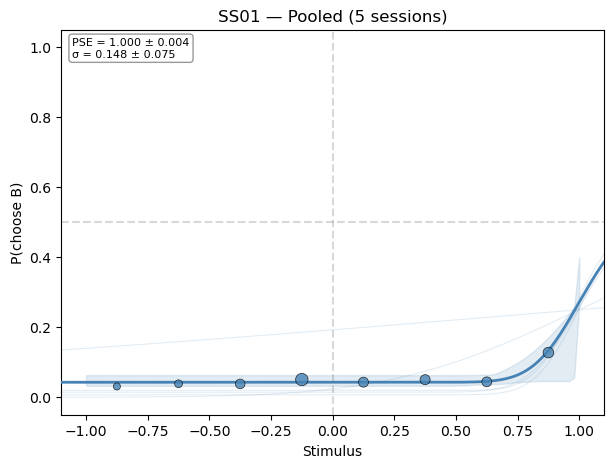

In [7]:
# ── Pooled with individual sessions visible ─────────────────────────────────
fig, ax, info = animal.plot_psychometric(
    mode='pooled', sessions='last_5',
    show_individual=True, n_bootstrap=200, show_ci=True,
)

In [36]:
uni = animal.get_sessions(distribution='Uniform')
len(uni)

38

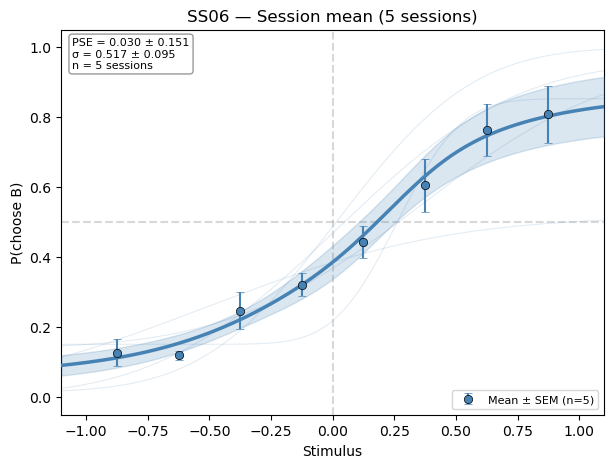

In [37]:
animal = experiment.get_animal('SS06')
# ── Session-mean with SEM ───────────────────────────────────────────────────
fig, ax, info = animal.plot_psychometric(
    mode='session_mean', sessions=[32, 33, 34, 35, 36],
    show_individual=True, show_ci=True,
)

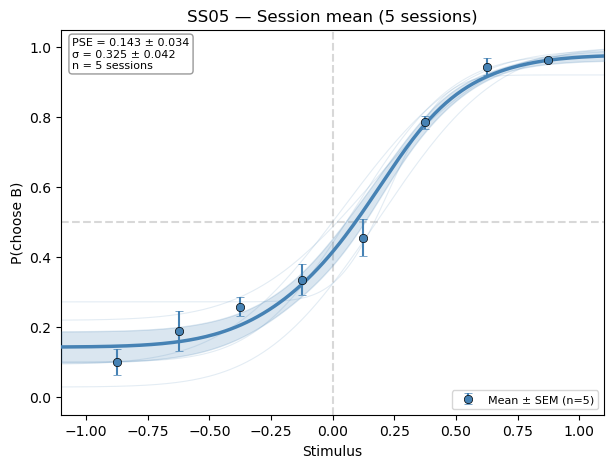

In [38]:
animal = experiment.get_animal('SS05')
# ── Session-mean with SEM ───────────────────────────────────────────────────
fig, ax, info = animal.plot_psychometric(
    mode='session_mean', sessions='last_5',
    show_individual=True, show_ci=True,
)

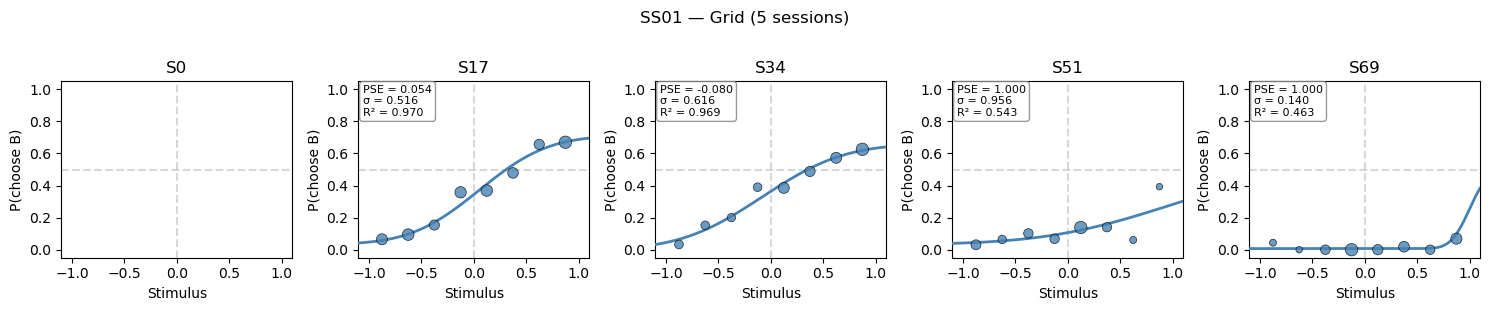

In [9]:
# ── Grid: snapshots across learning ─────────────────────────────────────────
snapshot_indices = np.linspace(0, n_sess - 1, min(5, n_sess), dtype=int).tolist()
fig, axes, infos = animal.plot_psychometric(
    mode='grid', sessions=snapshot_indices,
)

## 5. Summary Statistics

Two stat sets serve different purposes:
- **DEFAULT_STATS** (~5 stats): used by SBI for parameter inference
- **FEATURE_MATRIX_STATS** (~20 stats): used for SLDS and general characterisation

In [ ]:
print(f"Available stats ({len(list_available_stats())}):")
for s in sorted(list_available_stats()):
    print(f"  {s}")

In [ ]:
# ── Compare early vs late session ───────────────────────────────────────────
session_early = sessions[min(3, n_sess - 1)]
session_late = sessions[-1]

early_s = session_early.stats(['accuracy', 'psychometric', 'recency'])
late_s = session_late.stats(['accuracy', 'psychometric', 'recency'])

compare_stats = ['accuracy', 'pse', 'slope', 'lapse_low', 'lapse_high', 'recency']
header = f"{'Metric':<20} {'Early':<15} {'Late':<15}"
print(header)
print("-" * len(header))
for key in compare_stats:
    ev = early_s.get(key, np.nan)
    lv = late_s.get(key, np.nan)
    print(f"{key:<20} {ev:<15.3f} {lv:<15.3f}")

## 6. Feature Matrix

In [ ]:
df = build_feature_matrix(animal, stage=STAGE)
print(f"Feature matrix: {df.shape[0]} sessions × {df.shape[1]} columns")
print(f"\nNumeric columns: {sorted([c for c in df.columns if df[c].dtype in [np.float64, np.int64]])}")

## 7. Stat Trajectories

In [14]:
# ── Single animal: grid of key stats ────────────────────────────────────────
stats_to_plot = ['accuracy', 'pse', 'slope', 'recency',
                 'side_bias', 'choice_entropy', 'win_stay_rate']
stats_to_plot = [s for s in stats_to_plot if s in df.columns]

fig, axes = plot_stat_grid(
    [animal], stats=stats_to_plot, stage=STAGE,
    combine='none', show_individual=True,
)
plt.show()

NameError: name 'df' is not defined

In [ ]:
# ── Multi-animal: mean ± SEM ───────────────────────────────────────────────
all_animals = experiment.get_animals(min_sessions=MIN_SESSIONS, stage=STAGE)
if len(all_animals) > 1:
    fig, axes = plot_stat_grid(
        all_animals, stats=stats_to_plot, stage=STAGE,
        combine='mean_sem', show_individual=True, individual_alpha=0.2,
    )
    plt.show()
else:
    print("Need >1 animal for group-level trajectory plot")

## 8. Update Matrices

The update matrix captures serial dependence: how the previous trial's
stimulus shifts the current psychometric curve. This is the key statistic
that distinguishes BE from SC models.

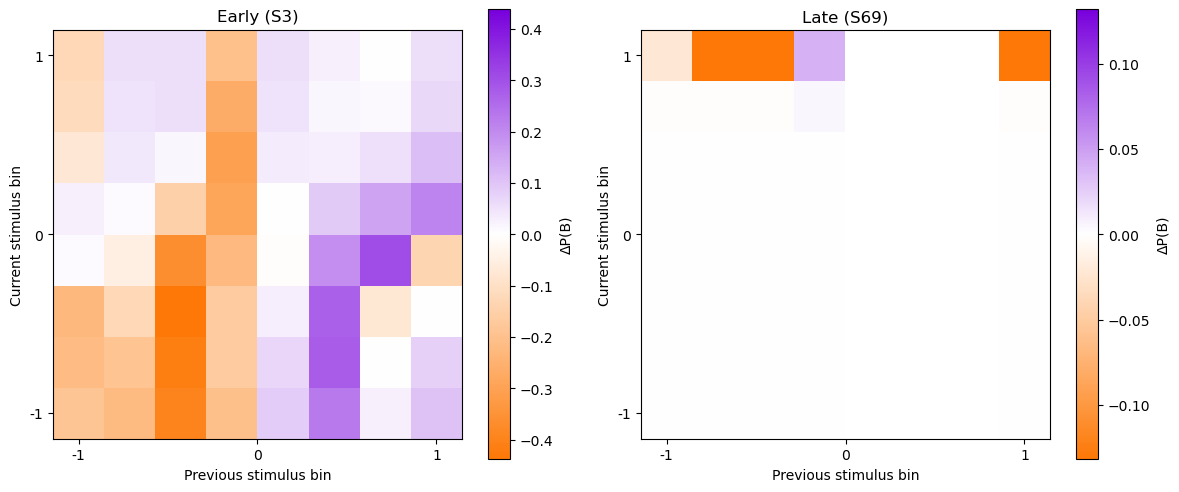

In [13]:
# ── Single session: naive vs expert ─────────────────────────────────────────
EARLY_IDX = min(3, n_sess - 1)
LATE_IDX = n_sess - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col, (sidx, label) in enumerate([(EARLY_IDX, 'Early'), (LATE_IDX, 'Late')]):
    sess = sessions[sidx]
    arrays = sess.trials.get_arrays(exclude_abort=True, exclude_opto=True)
    valid = ~arrays['no_response']
    s, c, cat = arrays['stimuli'][valid], arrays['choices'][valid], arrays['categories'][valid]
    um, _, _ = compute_update_matrix(s, c, cat, n_bins=8)
    plot_update_matrix(um, title=f'{label} (S{sidx})', ax=axes[col])
plt.tight_layout()
plt.show()

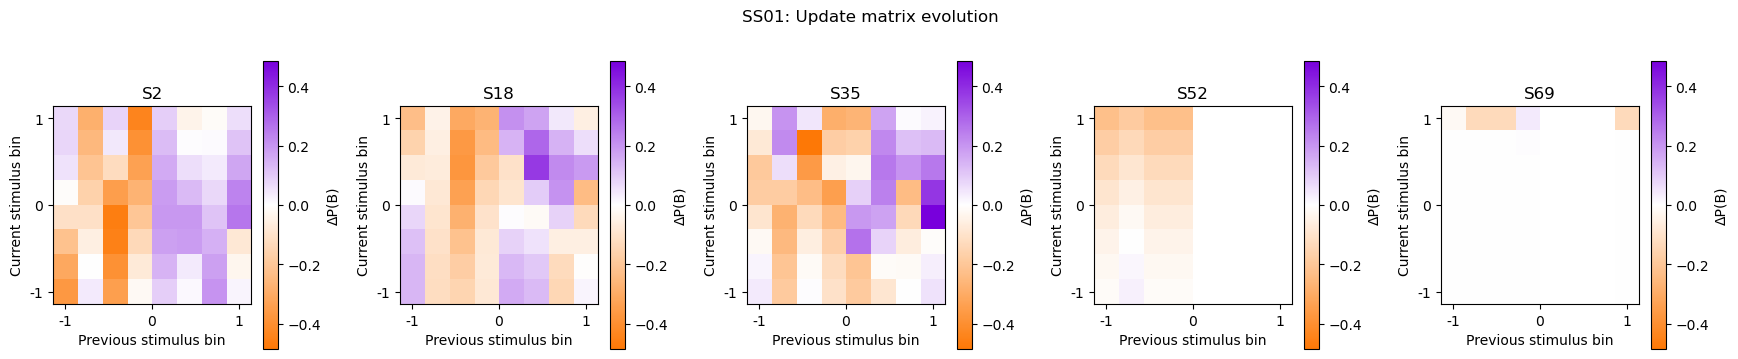

In [12]:
# ── Evolution across learning (5 snapshots) ─────────────────────────────────
snapshot_indices = np.linspace(2, n_sess - 1, min(5, n_sess - 2), dtype=int)
snapshot_indices = sorted(set(snapshot_indices))

ums = []
for sidx in snapshot_indices:
    sess = sessions[sidx]
    arrays = sess.trials.get_arrays(exclude_abort=True, exclude_opto=True)
    valid = ~arrays['no_response']
    s, c, cat = arrays['stimuli'][valid], arrays['choices'][valid], arrays['categories'][valid]
    um, _, _ = compute_update_matrix(s, c, cat, n_bins=8)
    ums.append(um)

vmax = max(
    np.nanmax(np.abs(um)) for um in ums if not np.all(np.isnan(um))
)

fig, axes = plt.subplots(1, len(snapshot_indices), figsize=(3.5 * len(snapshot_indices), 3.5))
if len(snapshot_indices) == 1:
    axes = [axes]
for i, (sidx, um) in enumerate(zip(snapshot_indices, ums)):
    plot_update_matrix(um, title=f'S{sidx}', ax=axes[i], vmin=-vmax, vmax=vmax)
fig.suptitle(f'{animal.animal_id}: Update matrix evolution', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'ums' is not defined

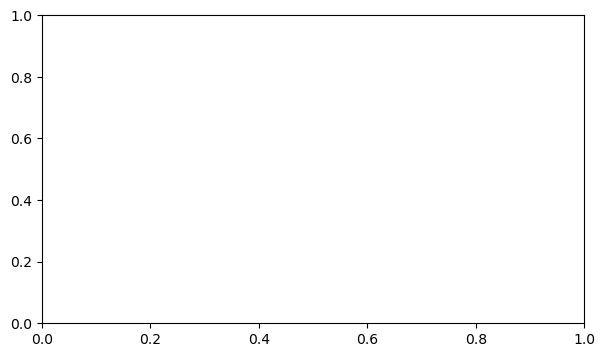

In [11]:
# ── Serial dependence profile (column-means of UM) ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
midpoints = np.linspace(-1, 1, 9)
midpoints = (midpoints[:-1] + midpoints[1:]) / 2
cmap = plt.cm.viridis

for i, (sidx, um) in enumerate(zip(snapshot_indices, ums)):
    profile = np.nanmean(um, axis=1)
    frac = i / max(len(snapshot_indices) - 1, 1)
    ax.plot(midpoints, profile, 'o-', color=cmap(frac), lw=1.5, ms=5,
            label=f'S{sidx}', alpha=0.8)

ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Previous stimulus bin')
ax.set_ylabel('Mean Δ P(B)')
ax.set_title(f'{animal.animal_id}: Serial dependence profile')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9. Multi-Animal Overview

In [10]:
# ── One row per animal: psychometric + stat trajectories ────────────────────
if len(all_animals) > 0:
    fig, axes = experiment.plot_overview(
        animals='all', sessions='last_5', stage=STAGE,
        stats=['accuracy', 'pse', 'recency'],
    )
    plt.show()

NameError: name 'all_animals' is not defined

## 10. Save / Reload

```python
experiment.save('experiment.pkl')
animal.save('SS05.pkl')

experiment = ExperimentData.load('experiment.pkl')
animal = AnimalData.load('SS05.pkl')
```